In [1]:
# ===== 0) Imports =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [16]:
# ===== 1) Load files (EDIT PATH) =====
# data_dir = Path(r"/Users/vladv/Econometrics/Project/CRSS2023CSV")

acc = pd.read_csv("accident.csv", low_memory=False)
veh = pd.read_csv("vehicle.csv", low_memory=False)
per = pd.read_csv("person.csv", low_memory=False)

print(f"accident.csv: {acc.shape}\n"
      f"vehicle.csv: {veh.shape}\n"
      f"person.csv: {per.shape}\n")

accident.csv: (50103, 80)
vehicle.csv: (87461, 169)
person.csv: (122388, 112)



In [5]:
# ===== 2) Helpers =====
def wsum(df, wcol="WEIGHT"):
    return df[wcol].sum()

def weighted_counts(df, group_col, wcol="WEIGHT"):
    out = df.groupby(group_col)[wcol].sum().sort_values(ascending=False).reset_index(name="w")
    out["share"] = out["w"] / out["w"].sum()
    return out

def weighted_rate(df, group_col, y_col, wcol="WEIGHT"):
    g = df.groupby(group_col).apply(lambda d: (d[wcol] * d[y_col]).sum() / d[wcol].sum() if d[wcol].sum()!=0 else np.nan)
    return g.reset_index(name="rate").sort_values("rate", ascending=False)

def to_season(month):
    if month in [12,1,2]: return "Winter"
    if month in [3,4,5]:  return "Spring"
    if month in [6,7,8]:  return "Summer"
    if month in [9,10,11]: return "Fall"
    return "Unknown"

def topn_plus_other(df, cat_col, wcol="WEIGHT", topn=10, other_label="Other"):
    top = df.groupby(cat_col)[wcol].sum().sort_values(ascending=False).head(topn).index
    out = df.copy()
    out[cat_col] = out[cat_col].where(out[cat_col].isin(top), other_label)
    return out

In [6]:
# ===== 3) Accident derived fields =====
acc2 = acc.copy()

# weights + time
wcol = "WEIGHT"
acc2["MONTH_USE"] = pd.to_numeric(acc2["MONTH"], errors="coerce")
acc2["HOUR_USE"] = pd.to_numeric(acc2["HOUR_IM"] if "HOUR_IM" in acc2.columns else acc2["HOUR"], errors="coerce")

# season
acc2["SEASON"] = acc2["MONTH_USE"].apply(lambda m: to_season(int(m)) if pd.notna(m) else "Unknown")
season_order = ["Winter","Spring","Summer","Fall","Unknown"]
acc2["SEASON"] = pd.Categorical(acc2["SEASON"], categories=season_order, ordered=True)

# day/night
acc2["NIGHT"] = (acc2["HOUR_USE"] >= 20) | (acc2["HOUR_USE"] <= 5)
acc2["DAYNIGHT"] = np.where(acc2["NIGHT"], "Night", "Day")

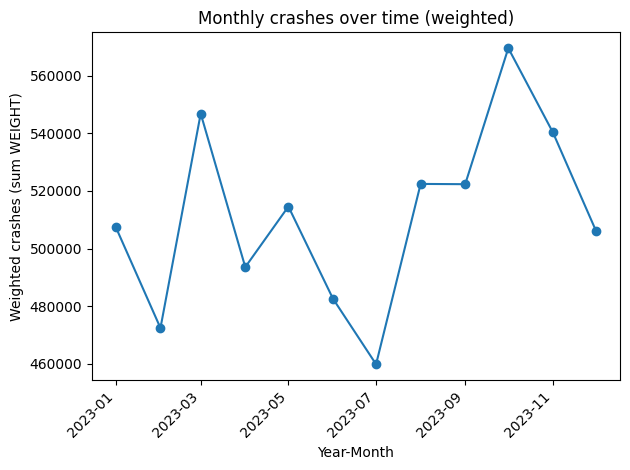

,YEAR,MONTH,weighted_crashes,date
0,2023,1,507388.035179,2023-01-01
1,2023,2,472467.172307,2023-02-01
2,2023,3,546841.140794,2023-03-01
3,2023,4,493605.907902,2023-04-01
4,2023,5,514613.409132,2023-05-01


In [7]:
# Graph 0: Time series of monthly crashes across all years (YEAR-MONTH), weighted

df = acc.copy()
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")
df["MONTH"] = pd.to_numeric(df["MONTH"], errors="coerce")
df["WEIGHT"] = pd.to_numeric(df["WEIGHT"], errors="coerce")

df = df.dropna(subset=["YEAR", "MONTH", "WEIGHT"])
df = df[(df["MONTH"] >= 1) & (df["MONTH"] <= 12)]

monthly = (
    df.groupby(["YEAR", "MONTH"], as_index=False)["WEIGHT"]
      .sum()
      .rename(columns={"WEIGHT": "weighted_crashes"})
      .sort_values(["YEAR", "MONTH"])
)

monthly["date"] = pd.to_datetime(
    monthly["YEAR"].astype(int).astype(str) + "-" + monthly["MONTH"].astype(int).astype(str) + "-01"
)

plt.figure()
plt.plot(monthly["date"], monthly["weighted_crashes"], marker="o")
plt.title("Monthly crashes over time (weighted)")
plt.xlabel("Year-Month")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

monthly.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26144\2540192711.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df.groupby(group_col)[wcol].sum().sort_values(ascending=False).reset_index(name="w")


,SEASON,w,share
2,Winter,1.486036e+06,0.242090
1,Spring,1.555060e+06,0.253335
3,Summer,1.465008e+06,0.238664
0,Fall,1.632255e+06,0.265911
4,Unknown,0.000000e+00,0.000000


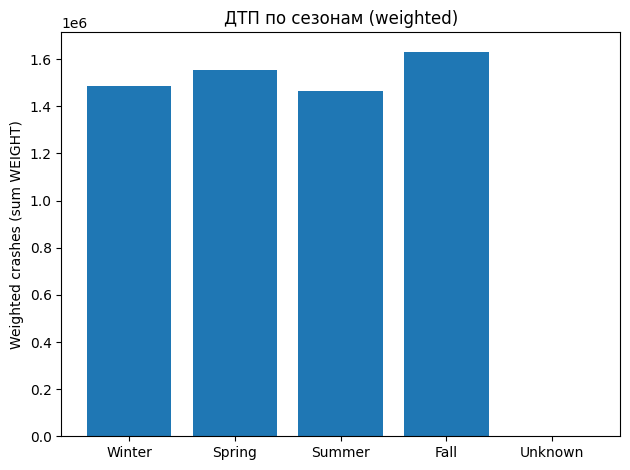

In [8]:
# ===== (1) ДТП по сезонам =====
tab_season = weighted_counts(acc2, "SEASON", wcol=wcol).sort_values("SEASON")

plt.figure()
plt.bar(tab_season["SEASON"].astype(str), tab_season["w"])
plt.title("ДТП по сезонам (weighted)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=0)
plt.tight_layout()
tab_season

,DAYNIGHT,w,share
0,Day,4.859363e+06,0.791639
1,Night,1.278996e+06,0.208361


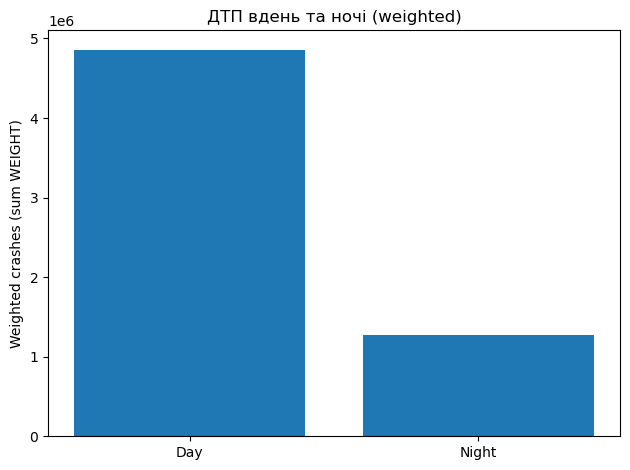

In [ ]:
# ===== (2) ДТП вдень та ночі =====
tab_daynight = weighted_counts(acc2, "DAYNIGHT", wcol=wcol)

plt.figure()
plt.bar(tab_daynight["DAYNIGHT"], tab_daynight["w"])
plt.title("ДТП вдень та ночі (weighted)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.tight_layout()
tab_daynight

In [ ]:
# ===== 4) Crash-level VALIGN from vehicle (event-level) =====
# pick VALIGN of the smallest VEH_NO per CASENUM (vehicle 1 if present), else first
veh2 = veh.copy()
veh2["VEH_NO"] = pd.to_numeric(veh2["VEH_NO"], errors="coerce")
valign_name_col = "VALIGNNAME" if "VALIGNNAME" in veh2.columns else "VALIGN"

veh2[valign_name_col] = veh2[valign_name_col].astype("string").fillna("Unknown")
veh2 = veh2.sort_values(["CASENUM","VEH_NO"])

crash_valign = veh2.groupby("CASENUM")[valign_name_col].first().reset_index(name="VALIGN_CRASH")
crash_valign["VALIGN_CRASH"] = crash_valign["VALIGN_CRASH"].fillna("Unknown")

# merge with accident weights (one row per crash)
crash_valign = crash_valign.merge(acc2[["CASENUM", wcol]], on="CASENUM", how="inner")
crash_valign.head()

,CASENUM,VALIGN_CRASH,WEIGHT
0,202304632910,Straight,210.860191
1,202304632916,Straight,217.379279
2,202304635310,Straight,223.420027
3,202304635315,Straight,25.966355
4,202304635387,Straight,134.139564


,VALIGN_CRASH,w,share
0,Straight,5.095559e+06,0.830117
1,Curve - Right,2.947078e+05,0.048011
2,Curve - Left,2.524827e+05,0.041132
3,Non-Trafficway or Driveway Access,2.314479e+05,0.037705
4,Not Reported,2.012628e+05,0.032788
5,Curve - Unknown Direction,5.704635e+04,0.009293
6,Reported as Unknown,5.852666e+03,0.000953


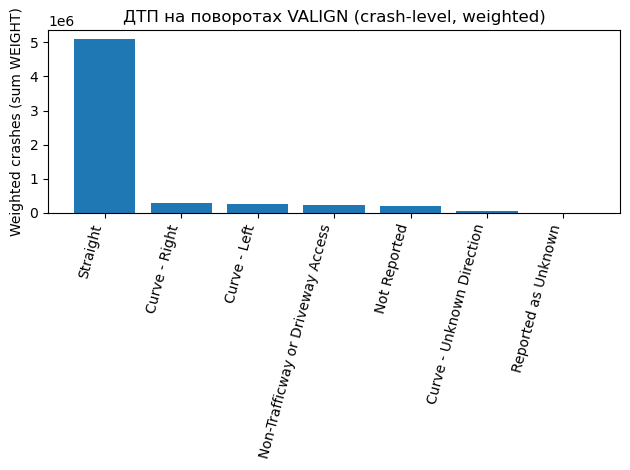

In [ ]:
# ===== (3) ДТП на поворотах VALIGN (як події) =====
crash_valign_top = topn_plus_other(crash_valign, "VALIGN_CRASH", wcol=wcol, topn=10)

tab_valign = weighted_counts(crash_valign_top, "VALIGN_CRASH", wcol=wcol)

plt.figure()
plt.bar(tab_valign["VALIGN_CRASH"].astype(str), tab_valign["w"])
plt.title("ДТП на поворотах VALIGN (crash-level, weighted)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
tab_valign

(   HOUR              w
 0     0  105864.069692
 1     1   80112.181347
 2     2   81804.628186
 3     3   69337.726476
 4     4   63260.313693,
          PEAK_LABEL             w     share
 0          Non-peak  3.879793e+06  0.632057
 1  Peak (7-9,16-18)  2.258566e+06  0.367943)

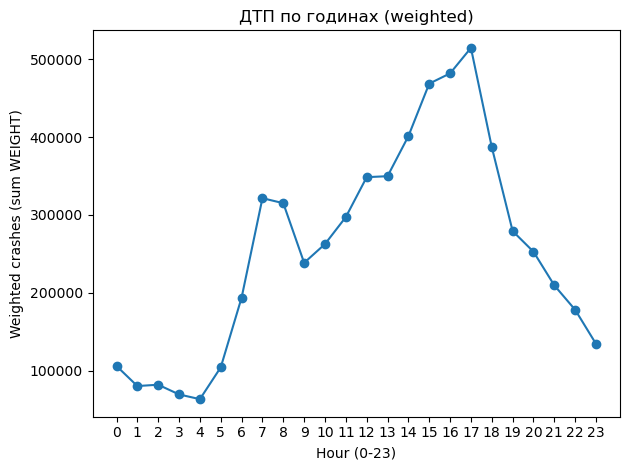

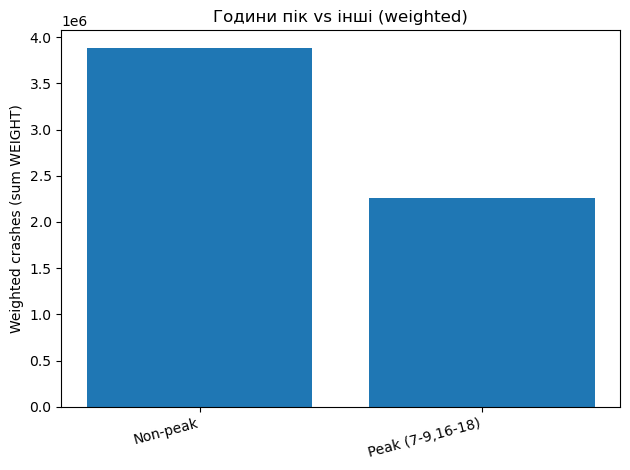

In [ ]:
# ===== (4) У години пік більше ДТП =====
hour_counts = acc2.dropna(subset=["HOUR_USE"]).groupby("HOUR_USE")[wcol].sum().reindex(range(24), fill_value=0).reset_index()
hour_counts.columns = ["HOUR", "w"]

plt.figure()
plt.plot(hour_counts["HOUR"], hour_counts["w"], marker="o")
plt.title("ДТП по годинах (weighted)")
plt.xlabel("Hour (0-23)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(range(24))
plt.tight_layout()
print("Hello, World!")
# peak vs non-peak
peak_hours = set([7,8,9,16,17,18])
acc2["PEAK"] = acc2["HOUR_USE"].isin(list(peak_hours))
acc2["PEAK_LABEL"] = np.where(acc2["PEAK"], "Peak (7-9,16-18)", "Non-peak")

tab_peak = weighted_counts(acc2.dropna(subset=["HOUR_USE"]), "PEAK_LABEL", wcol=wcol)

plt.figure()
plt.bar(tab_peak["PEAK_LABEL"], tab_peak["w"])
plt.title("Години пік vs інші (weighted)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

hour_counts.head(), tab_peak

In [12]:
[c for c in per2.columns if "WEIGHT" in c]

NameError: name 'per2' is not defined

/var/folders/53/tzqf15nx4_b7j93fk5xvykhr0000gn/T/ipykernel_77259/1704535015.py:62: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

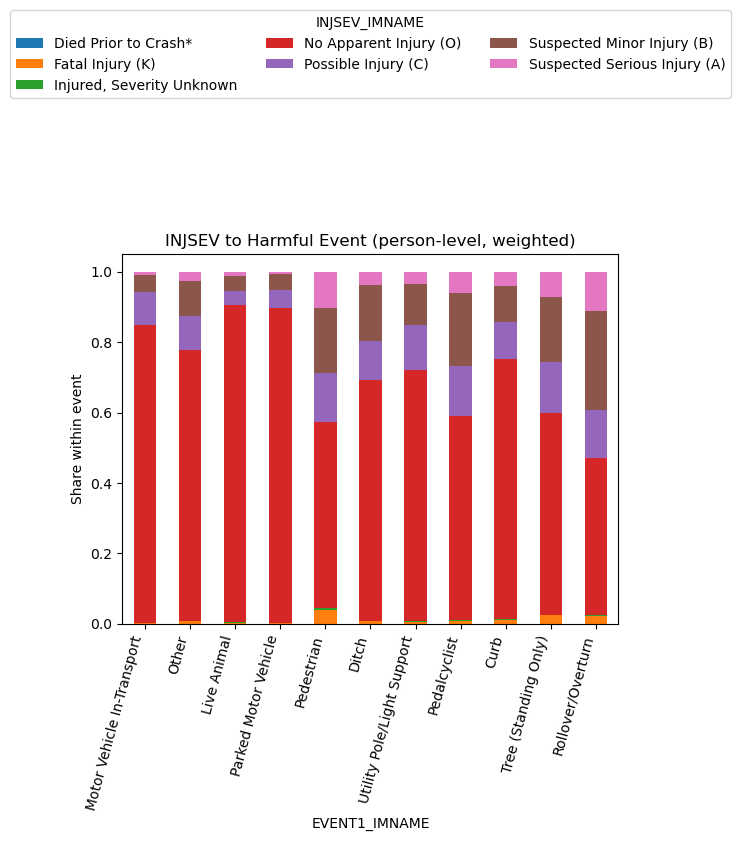

In [ ]:
# ===== 5) INJSEV to HARM_EV (person-level) — robust version =====

# 1) pick injury severity column in person
inj_col = None
for cand in ["INJSEV_IMNAME", "INJ_SEVNAME", "INJSEVNAME", "INJSEV_IM", "INJ_SEV", "INJSEV"]:
    if cand in per.columns:
        inj_col = cand
        break
if inj_col is None:
    raise ValueError("Could not find injury severity column in person.csv")

# 2) pick harmful event column in accident (prefer imputed name if exists)
harm_col = None
for cand in ["EVENT1_IMNAME", "HARM_EVNAME", "EVENT1_IM", "HARM_EV"]:
    if cand in acc.columns:
        harm_col = cand
        break
if harm_col is None:
    raise ValueError("Could not find harmful event column in accident.csv")

# 3) merge (explicit suffixes so weights become WEIGHT_PER / WEIGHT_ACC)
per2 = per.copy()
per2[inj_col] = per2[inj_col].astype("string").fillna("Unknown")

per2 = per2.merge(
    acc[["CASENUM", harm_col, "WEIGHT"]],
    on="CASENUM",
    how="left",
    suffixes=("_PER", "_ACC")
)

# 4) choose person-level weight if present, else crash-level weight
w_person = "WEIGHT_PER" if "WEIGHT_PER" in per2.columns else "WEIGHT_ACC"
per2[w_person] = pd.to_numeric(per2[w_person], errors="coerce").fillna(0)

per2[harm_col] = per2[harm_col].astype("string").fillna("Unknown")

# 5) top 10 events by weighted persons
top_events = per2.groupby(harm_col)[w_person].sum().sort_values(ascending=False).head(10).index
per3 = per2.copy()
per3[harm_col] = per3[harm_col].where(per3[harm_col].isin(top_events), "Other")

# 6) weighted distribution of injury severity within each event
pivot = per3.pivot_table(values=w_person, index=harm_col, columns=inj_col, aggfunc="sum", fill_value=0)
share = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0)

# order bars by total weight
order = per3.groupby(harm_col)[w_person].sum().sort_values(ascending=False).index
share = share.loc[order]

# 7) plot with legend at bottom
plt.figure()
ax = share.plot(kind="bar", stacked=True)

plt.title("INJSEV to Harmful Event (person-level, weighted)")
plt.ylabel("Share within event")
plt.xlabel(harm_col)
plt.xticks(rotation=75, ha="right")

ax.legend(title=inj_col, loc="upper center", bbox_to_anchor=(0.5, 1.68), ncol=3)

plt.tight_layout()
plt.show()

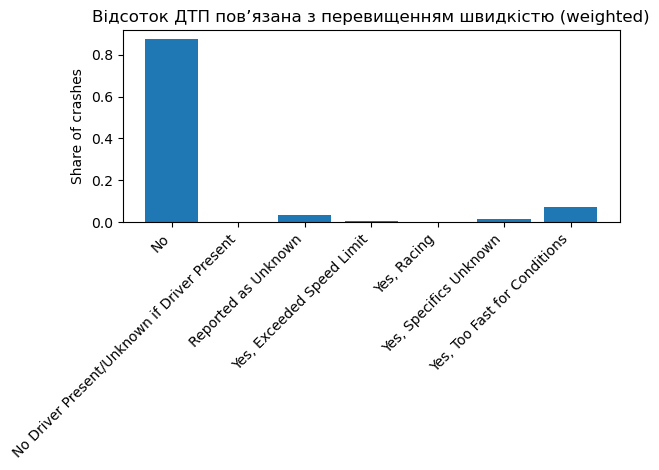

In [ ]:
# ===== Speed-related crash percent (crash-level, weighted) =====

# crash-level SPEEDREL from vehicle: take VEH_NO==1 if present else smallest VEH_NO
veh2 = veh.copy()
veh2["VEH_NO"] = pd.to_numeric(veh2["VEH_NO"], errors="coerce")
veh2 = veh2.sort_values(["CASENUM", "VEH_NO"])

speedrel_col = "SPEEDRELNAME" if "SPEEDRELNAME" in veh2.columns else "SPEEDREL"
veh2[speedrel_col] = veh2[speedrel_col].astype("string").fillna("Unknown")

crash_speedrel = veh2.groupby("CASENUM")[speedrel_col].first().reset_index(name="SPEEDREL_CRASH")
crash_speedrel = crash_speedrel.merge(acc[["CASENUM","WEIGHT"]], on="CASENUM", how="inner")

tab = crash_speedrel.groupby("SPEEDREL_CRASH")["WEIGHT"].sum().reset_index(name="weighted_crashes")
tab["share"] = tab["weighted_crashes"] / tab["weighted_crashes"].sum()

plt.figure()
plt.bar(tab["SPEEDREL_CRASH"].astype(str), tab["share"])
plt.title("Відсоток ДТП пов’язана з перевищенням швидкістю (weighted)")
plt.ylabel("Share of crashes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

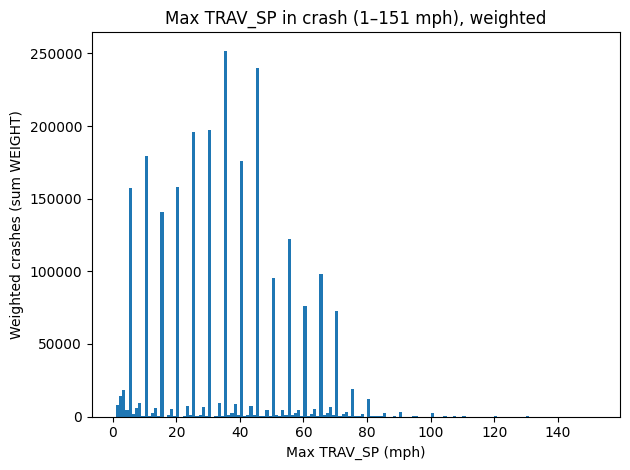

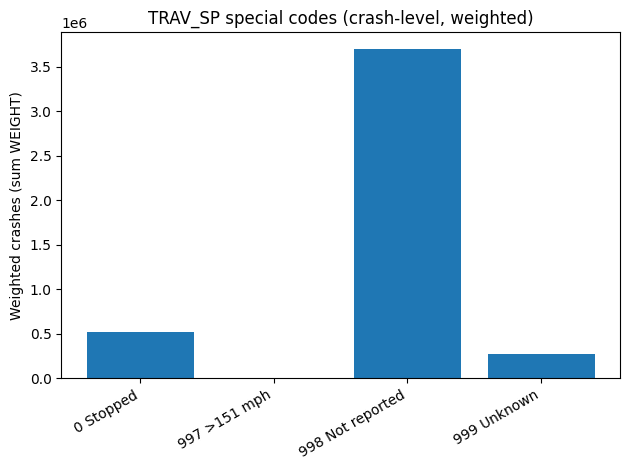

    BIN  weighted_crashes
   1-10            399114
  11-20            313785
  21-30            410168
  31-40            451786
  41-50            349663
  51-60            213510
  61-70            189633
  71-80             38582
  81-90              7035
 91-100              3719
101-110               465
111-120               304
121-130               358
131-140                10
141-151                54
Weighted crashes with any 997 (>151 mph): 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_26144\1302982730.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cs.groupby("BIN")["WEIGHT"].sum()


In [9]:
# --- assumes you already loaded:
# acc = pd.read_csv(.../accident.csv)
# veh = pd.read_csv(.../vehicle.csv)

# ===== 1) Crash weights =====
crash_w = acc[["CASENUM", "WEIGHT"]].copy()
crash_w["WEIGHT"] = pd.to_numeric(crash_w["WEIGHT"], errors="coerce")

# ===== 2) Vehicle speeds =====
v = veh[["CASENUM", "TRAV_SP"]].copy()
v["TRAV_SP"] = pd.to_numeric(v["TRAV_SP"], errors="coerce")
v = v.dropna(subset=["CASENUM", "TRAV_SP"])

# ===== 3) Max REAL speed per crash (1..151 only) =====
v_real = v[(v["TRAV_SP"] >= 1) & (v["TRAV_SP"] <= 151)].copy()
max_real = v_real.groupby("CASENUM")["TRAV_SP"].max().reset_index(name="MAX_TRAV_SP_REAL")

# ===== 4) Special codes per crash: 0/997/998/999 (presence) =====
special_codes = [0, 997, 998, 999]
v_special = v[v["TRAV_SP"].isin(special_codes)].copy()

# pick ONE special code per crash (priority: 997 > 998 > 999 > 0)
priority = {997: 4, 998: 3, 999: 2, 0: 1}
special_one = (
    v_special.assign(prio=v_special["TRAV_SP"].map(priority))
    .sort_values(["CASENUM", "prio"], ascending=[True, False])
    .groupby("CASENUM")["TRAV_SP"]
    .first()
    .reset_index(name="SPECIAL_TRAV_SP")
)

# ===== 5) Build crash-level dataset =====
crash_speed = (
    crash_w.merge(max_real, on="CASENUM", how="left")
           .merge(special_one, on="CASENUM", how="left")
           .dropna(subset=["WEIGHT"])
)

# ===== A) Histogram: max real speeds (1..151) =====
real = crash_speed.dropna(subset=["MAX_TRAV_SP_REAL"]).copy()

bins_real = np.arange(1, 153, 1)
cnt_real, _ = np.histogram(real["MAX_TRAV_SP_REAL"], bins=bins_real, weights=real["WEIGHT"])
ymax = (cnt_real.max() if len(cnt_real) else 0) * 1.05

plt.figure()
plt.hist(real["MAX_TRAV_SP_REAL"], bins=bins_real, weights=real["WEIGHT"])
plt.title("Max TRAV_SP in crash (1–151 mph), weighted")
plt.xlabel("Max TRAV_SP (mph)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.ylim(0, ymax)
plt.tight_layout()
plt.show()

# ===== B) Bar chart: special codes 0/997/998/999 =====
labels = {
    0: "0 Stopped",
    997: "997 >151 mph",
    998: "998 Not reported",
    999: "999 Unknown",
}

special = crash_speed.dropna(subset=["SPECIAL_TRAV_SP"]).copy()
special["label"] = special["SPECIAL_TRAV_SP"].map(labels).fillna("Other")

tab_special = (
    special.groupby("label")["WEIGHT"].sum()
    .reindex(list(labels.values()), fill_value=0)
    .reset_index(name="weighted_crashes")
)

plt.figure()
plt.bar(tab_special["label"], tab_special["weighted_crashes"])
plt.title("TRAV_SP special codes (crash-level, weighted)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# ===== C) Print crash counts by 10-mph bins (based on MAX real speed) =====
cs = real.copy()

# 10-mph bins with last bin ending at 151: 1-10, 11-20, ..., 141-151
edges = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,151]
labels10 = [f"{edges[i]+1}-{edges[i+1]}" for i in range(len(edges)-1)]

cs["BIN"] = pd.cut(
    cs["MAX_TRAV_SP_REAL"],
    bins=edges,
    right=True,
    include_lowest=True,
    labels=labels10
)

tab_bins = (
    cs.groupby("BIN")["WEIGHT"].sum()
      .reindex(labels10, fill_value=0)
      .reset_index()
      .rename(columns={"WEIGHT": "weighted_crashes"})
)

tab_bins["weighted_crashes"] = tab_bins["weighted_crashes"].round(0).astype(int)
print(tab_bins.to_string(index=False))

# ===== D) Quick check: weighted crashes where any vehicle had 997 (>151 mph) =====
w_997 = crash_speed.loc[crash_speed["SPECIAL_TRAV_SP"] == 997, "WEIGHT"].sum()
print("Weighted crashes with any 997 (>151 mph):", int(round(w_997)))


 ANALYZING: Northeast 


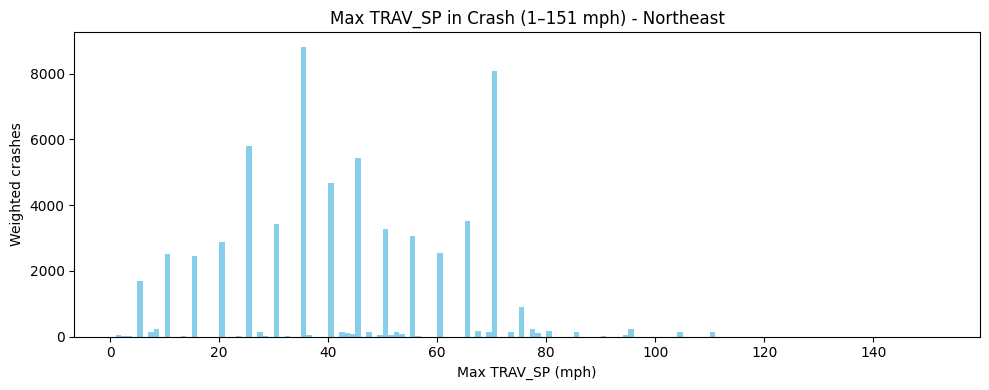

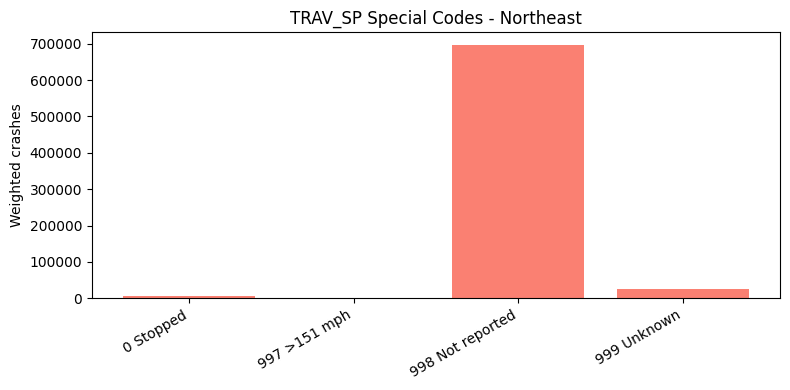

Speed Distribution for Northeast:
    BIN  weighted_crashes
   1-10              4663
  11-20              5382
  21-30              9418
  31-40             13555
  41-50              9204
  51-60              5874
  61-70             11904
  71-80              1546
  81-90               170
 91-100               268
101-110               289
111-120                 0
121-130                 0
131-140                 0
141-151                 0
Weighted crashes with any 997 (>151 mph) in Northeast: 0

 ANALYZING: Midwest 


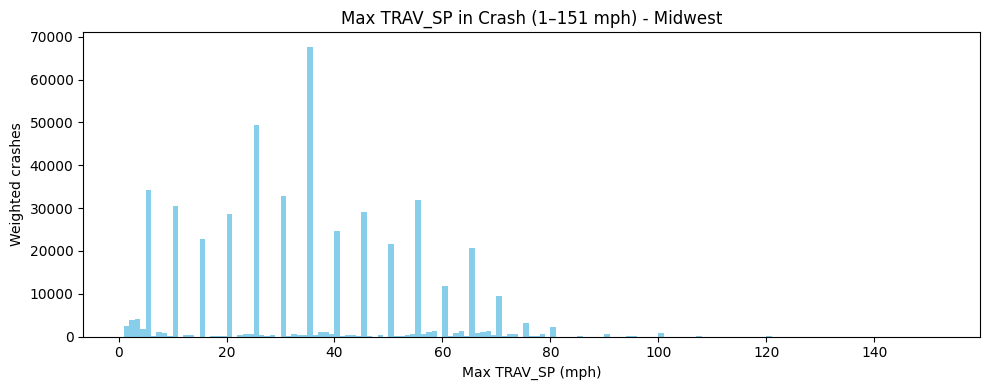

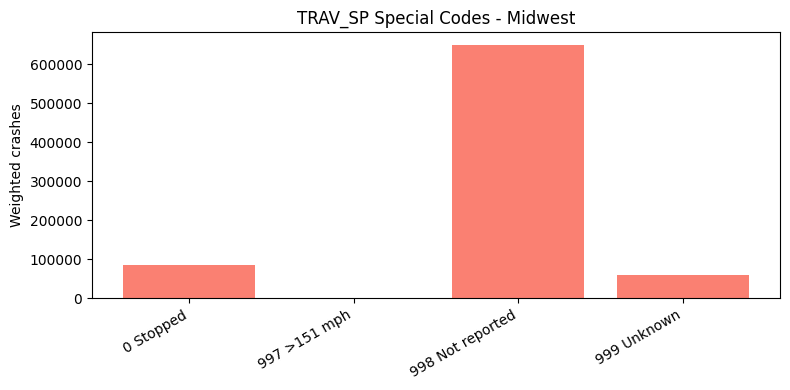

Speed Distribution for Midwest:
    BIN  weighted_crashes
   1-10             79000
  11-20             52503
  21-30             84686
  31-40             96746
  41-50             52077
  51-60             47934
  61-70             36145
  71-80              7195
  81-90               624
 91-100               976
101-110                25
111-120                51
121-130                 0
131-140                 0
141-151                 0
Weighted crashes with any 997 (>151 mph) in Midwest: 0

 ANALYZING: South 


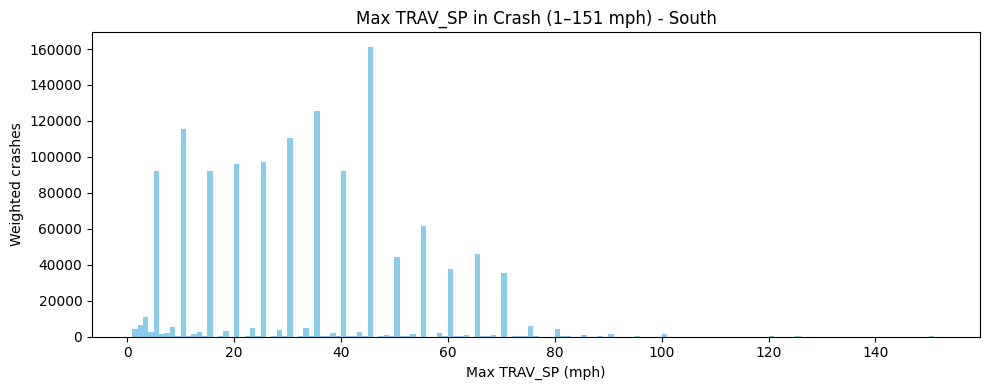

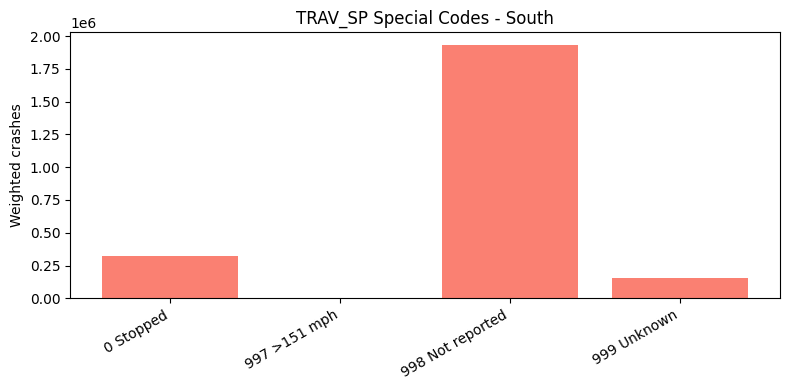

Speed Distribution for South:
    BIN  weighted_crashes
   1-10            240618
  11-20            196177
  21-30            216992
  31-40            225786
  41-50            210167
  51-60            102747
  61-70             83455
  71-80             11193
  81-90              2760
 91-100              1727
101-110                26
111-120               227
121-130                54
131-140                10
141-151                54
Weighted crashes with any 997 (>151 mph) in South: 0

 ANALYZING: West 


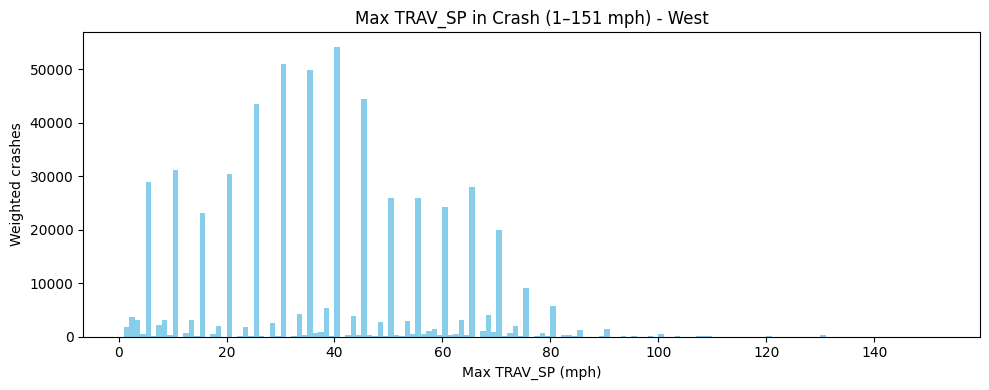

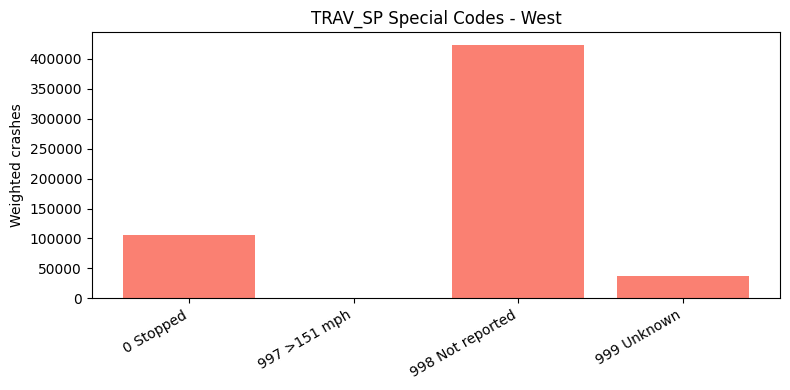

Speed Distribution for West:
    BIN  weighted_crashes
   1-10             74833
  11-20             59723
  21-30             99072
  31-40            115698
  41-50             78214
  51-60             56955
  61-70             58129
  71-80             18649
  81-90              3481
 91-100               748
101-110               124
111-120                26
121-130               304
131-140                 0
141-151                 0
Weighted crashes with any 997 (>151 mph) in West: 0


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mapping for Census Regions (standard in CRSS)
# If your data uses NHTSA Regions 1-10, you can update this dictionary
region_labels = {
    1: "Northeast",
    2: "Midwest",
    3: "South",
    4: "West"
}

def analyze_speeds_by_region(acc_df, veh_df):
    # Ensure regions exist
    if 'REGION' not in acc_df.columns:
        print("Column 'REGION' not found in accident data.")
        return

    # Get unique regions present in the data
    regions = sorted(acc_df['REGION'].unique())

    for reg_id in regions:
        reg_name = region_labels.get(reg_id, f"Region {reg_id}")
        print(f"\n{'='*40}")
        print(f" ANALYZING: {reg_name} ")
        print(f"{'='*40}")

        # --- Filter data for the current region ---
        acc_sub = acc_df[acc_df['REGION'] == reg_id].copy()
        # Only include vehicles involved in crashes within this region
        veh_sub = veh_df[veh_df['CASENUM'].isin(acc_sub['CASENUM'])].copy()

        # ===== 1) Crash weights =====
        crash_w = acc_sub[["CASENUM", "WEIGHT"]].copy()
        crash_w["WEIGHT"] = pd.to_numeric(crash_w["WEIGHT"], errors="coerce")

        # ===== 2) Vehicle speeds =====
        v = veh_sub[["CASENUM", "TRAV_SP"]].copy()
        v["TRAV_SP"] = pd.to_numeric(v["TRAV_SP"], errors="coerce")
        v = v.dropna(subset=["CASENUM", "TRAV_SP"])

        # ===== 3) Max REAL speed per crash (1..151 only) =====
        v_real = v[(v["TRAV_SP"] >= 1) & (v["TRAV_SP"] <= 151)].copy()
        max_real = v_real.groupby("CASENUM")["TRAV_SP"].max().reset_index(name="MAX_TRAV_SP_REAL")

        # ===== 4) Special codes per crash =====
        special_codes = [0, 997, 998, 999]
        priority = {997: 4, 998: 3, 999: 2, 0: 1}
        v_special = v[v["TRAV_SP"].isin(special_codes)].copy()

        special_one = (
            v_special.assign(prio=v_special["TRAV_SP"].map(priority))
            .sort_values(["CASENUM", "prio"], ascending=[True, False])
            .groupby("CASENUM")["TRAV_SP"]
            .first()
            .reset_index(name="SPECIAL_TRAV_SP")
        )

        # ===== 5) Build crash-level dataset =====
        crash_speed = (
            crash_w.merge(max_real, on="CASENUM", how="left")
                   .merge(special_one, on="CASENUM", how="left")
                   .dropna(subset=["WEIGHT"])
        )

        # ===== A) Histogram: Max real speeds =====
        real = crash_speed.dropna(subset=["MAX_TRAV_SP_REAL"]).copy()
        if not real.empty:
            bins_real = np.arange(1, 153, 1)
            cnt_real, _ = np.histogram(real["MAX_TRAV_SP_REAL"], bins=bins_real, weights=real["WEIGHT"])
            ymax = (cnt_real.max() if len(cnt_real) else 0) * 1.05

            plt.figure(figsize=(10, 4))
            plt.hist(real["MAX_TRAV_SP_REAL"], bins=bins_real, weights=real["WEIGHT"], color='skyblue', edgecolor='none')
            plt.title(f"Max TRAV_SP in Crash (1–151 mph) - {reg_name}")
            plt.xlabel("Max TRAV_SP (mph)")
            plt.ylabel("Weighted crashes")
            plt.ylim(0, ymax)
            plt.tight_layout()
            plt.show()

        # ===== B) Bar chart: Special codes =====
        labels_map = {
            0: "0 Stopped",
            997: "997 >151 mph",
            998: "998 Not reported",
            999: "999 Unknown",
        }

        special = crash_speed.dropna(subset=["SPECIAL_TRAV_SP"]).copy()
        if not special.empty:
            special["label"] = special["SPECIAL_TRAV_SP"].map(labels_map).fillna("Other")
            tab_special = (
                special.groupby("label")["WEIGHT"].sum()
                .reindex(list(labels_map.values()), fill_value=0)
                .reset_index(name="weighted_crashes")
            )

            plt.figure(figsize=(8, 4))
            plt.bar(tab_special["label"], tab_special["weighted_crashes"], color='salmon')
            plt.title(f"TRAV_SP Special Codes - {reg_name}")
            plt.ylabel("Weighted crashes")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()

        # ===== C) Print 10-mph bins =====
        if not real.empty:
            edges = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,151]
            labels10 = [f"{edges[i]+1}-{edges[i+1]}" for i in range(len(edges)-1)]

            real["BIN"] = pd.cut(
                real["MAX_TRAV_SP_REAL"],
                bins=edges,
                right=True,
                include_lowest=True,
                labels=labels10
            )

            tab_bins = (
                real.groupby("BIN", observed=False)["WEIGHT"].sum()
                  .reindex(labels10, fill_value=0)
                  .reset_index()
                  .rename(columns={"WEIGHT": "weighted_crashes"})
            )
            tab_bins["weighted_crashes"] = tab_bins["weighted_crashes"].round(0).astype(int)
            print(f"Speed Distribution for {reg_name}:")
            print(tab_bins.to_string(index=False))

        # ===== D) Quick check: 997 (>151 mph) =====
        w_997 = crash_speed.loc[crash_speed["SPECIAL_TRAV_SP"] == 997, "WEIGHT"].sum()
        print(f"Weighted crashes with any 997 (>151 mph) in {reg_name}:", int(round(w_997)))

# To execute:
analyze_speeds_by_region(acc, veh)

In [14]:
import pandas as pd
import numpy as np

# 1) Clean and Prepare Speeds (Vehicle Level)
v = veh[["CASENUM", "TRAV_SP"]].copy()
v["TRAV_SP"] = pd.to_numeric(v["TRAV_SP"], errors="coerce")

# Filter for "Real" speeds only (1 to 151 mph)
# This excludes codes 0 (Stopped), 997 (Greater than 151), 998 (Not Reported), and 999 (Unknown)
v_clean = v[(v["TRAV_SP"] >= 1) & (v["TRAV_SP"] <= 151)].dropna(subset=["TRAV_SP"])

# 2) Prepare Region and Weight Data (Accident Level)
a = acc[["CASENUM", "REGION", "WEIGHT"]].copy()
a["WEIGHT"] = pd.to_numeric(a["WEIGHT"], errors="coerce")

# 3) Merge Datasets
merged = v_clean.merge(a, on="CASENUM", how="inner")

# 4) Compute Raw Median Speed per Region
median_speeds = merged.groupby("REGION")["TRAV_SP"].median().reset_index()
median_speeds.columns = ["REGION", "RAW_MEDIAN_SPEED"]

# 5) Optional: Compute Weighted Median Speed per Region
# (This better represents the population of crashes)
def weighted_median(df, val_col, weight_col):
    df_sorted = df.sort_values(val_col)
    cumsum = df_sorted[weight_col].cumsum()
    cutoff = df_sorted[weight_col].sum() / 2.0
    return df_sorted[cumsum >= cutoff][val_col].iloc[0]

weighted_medians = (
    merged.groupby("REGION")
    .apply(lambda x: weighted_median(x, "TRAV_SP", "WEIGHT"))
    .reset_index(name="WEIGHTED_MEDIAN_SPEED")
)

# Combine and Display
results = median_speeds.merge(weighted_medians, on="REGION")
print(results)

   REGION  RAW_MEDIAN_SPEED  WEIGHTED_MEDIAN_SPEED
0       1              35.0                     35
1       2              30.0                     27
2       3              30.0                     25
3       4              35.0                     35


C:\Users\Admin\AppData\Local\Temp\ipykernel_26144\1289284390.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_median(x, "TRAV_SP", "WEIGHT"))


/var/folders/53/tzqf15nx4_b7j93fk5xvykhr0000gn/T/ipykernel_77259/1893501433.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p.groupby(["AGE_BIN", "SEX_LBL"])[wcol].sum()


<Figure size 640x480 with 0 Axes>

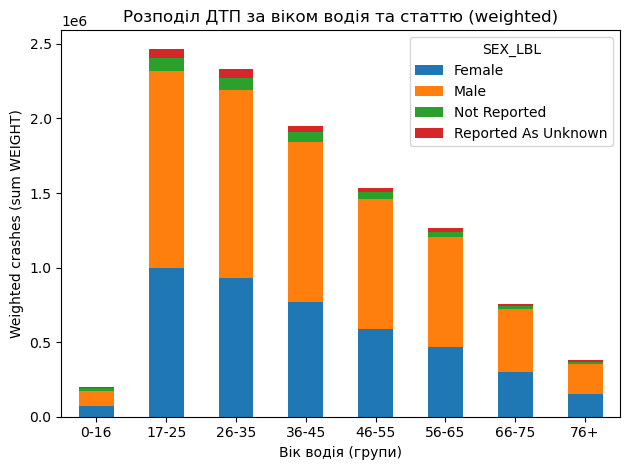

AGE_BIN             SEX_LBL  weighted_crashes
   0-16              Female             74555
   0-16                Male             95065
   0-16        Not Reported             20493
   0-16 Reported As Unknown             11462
  17-25              Female            998827
  17-25                Male           1321113
  17-25        Not Reported             85941
  17-25 Reported As Unknown             61864
  26-35              Female            932165
  26-35                Male           1262215
  26-35        Not Reported             79198
  26-35 Reported As Unknown             58920
  36-45              Female            769535
  36-45                Male           1071696
  36-45        Not Reported             65731
  36-45 Reported As Unknown             43522
  46-55              Female            591355
  46-55                Male            870639
  46-55        Not Reported             44668
  46-55 Reported As Unknown             27432
  56-65              Female       

In [ ]:
# expects: acc and per already loaded

age_col = "AGE_IM" if "AGE_IM" in per.columns else ("AGE" if "AGE" in per.columns else None)
sex_col = "SEXNAME" if "SEXNAME" in per.columns else ("SEX" if "SEX" in per.columns else None)
pertyp_col = "PER_TYP" if "PER_TYP" in per.columns else None

if age_col is None or sex_col is None or pertyp_col is None:
    raise ValueError("Need AGE/AGE_IM, SEX/SEXNAME, and PER_TYP in person.csv")

p = per.copy()
p[age_col] = pd.to_numeric(p[age_col], errors="coerce")

# drivers only (PER_TYP==1 is typical)
p = p[p[pertyp_col] == 1].dropna(subset=[age_col])

# merge accident weights (creates WEIGHT_x / WEIGHT_y if person already has WEIGHT)
p = p.merge(acc[["CASENUM", "WEIGHT"]], on="CASENUM", how="inner")

# choose weight column safely
if "WEIGHT_x" in p.columns:
    wcol = "WEIGHT_x"   # person weight
elif "WEIGHT" in p.columns:
    wcol = "WEIGHT"
elif "WEIGHT_y" in p.columns:
    wcol = "WEIGHT_y"   # fallback
else:
    raise ValueError("No weight column found after merge")

p[wcol] = pd.to_numeric(p[wcol], errors="coerce").fillna(0)

# normalize gender
p["SEX_LBL"] = p[sex_col].astype("string").fillna("Unknown").str.strip().str.title()

# age bins
bins = [0, 16, 25, 35, 45, 55, 65, 75, 120]
labels = ["0-16", "17-25", "26-35", "36-45", "46-55", "56-65", "66-75", "76+"]

p["AGE_BIN"] = pd.cut(p[age_col], bins=bins, labels=labels, right=True, include_lowest=True)

# weighted counts
tab = (
    p.groupby(["AGE_BIN", "SEX_LBL"])[wcol].sum()
     .reset_index(name="weighted_crashes")
)

wide = tab.pivot(index="AGE_BIN", columns="SEX_LBL", values="weighted_crashes").fillna(0)
wide = wide.reindex(labels)

plt.figure()
ax = wide.plot(kind="bar", stacked=True)
plt.title("Розподіл ДТП за віком водія та статтю (weighted)")
plt.xlabel("Вік водія (групи)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# print table under plot
tab_print = tab.copy()
tab_print["weighted_crashes"] = tab_print["weighted_crashes"].round(0).astype(int)
print(tab_print.sort_values(["AGE_BIN", "SEX_LBL"]).to_string(index=False))

print("Used weight column:", wcol)

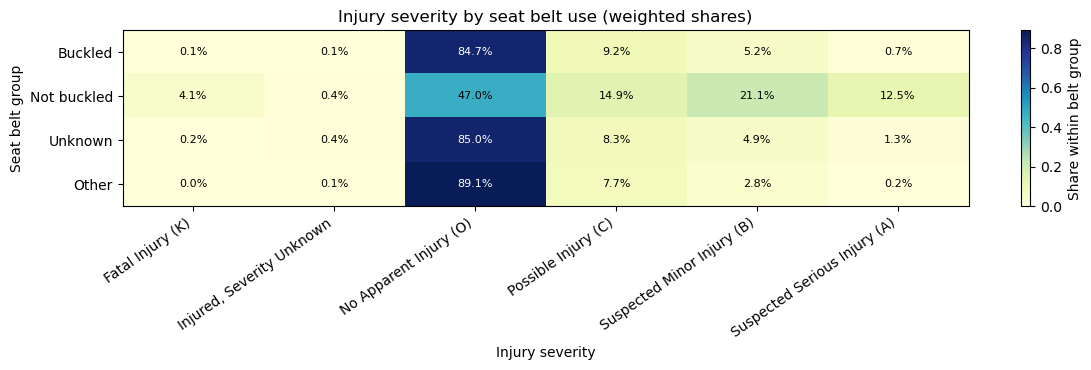

INJSEV_IMNAME  Fatal Injury (K)  Injured, Severity Unknown  No Apparent Injury (O)  Possible Injury (C)  Suspected Minor Injury (B)  Suspected Serious Injury (A)
BELT_GRP                                                                                                                                                         
Buckled                    0.10                       0.08                   84.74                 9.24                        5.17                          0.67
Not buckled                4.10                       0.41                   47.03                14.91                       21.07                         12.47
Unknown                    0.17                       0.39                   85.02                 8.26                        4.88                          1.27
Other                      0.05                       0.06                   89.11                 7.72                        2.85                          0.21


In [12]:
inj_col = None
for cand in ["INJSEV_IMNAME", "INJ_SEVNAME", "INJSEVNAME", "INJSEV_IM", "INJ_SEV", "INJSEV"]:
    if cand in per.columns:
        inj_col = cand
        break
if inj_col is None:
    raise ValueError("Injury severity column not found in person.csv")

belt_col = None
for cand in ["RESTUSE_IMNAME", "REST_USE_IMNAME", "REST_USENAME", "REST_USE",
             "RESTUSE_IM", "REST_USE_IM", "RESTUSE"]:
    if cand in per.columns:
        belt_col = cand
        break
if belt_col is None:
    raise ValueError("Restraint/belt column not found in person.csv")

# ---- base frame ----
p = per.copy()

# keep occupants (drivers/passengers)
if "PER_TYP" in p.columns:
    p = p[p["PER_TYP"].isin([1, 2])].copy()

p[inj_col] = p[inj_col].astype("string").fillna("Unknown")
p[belt_col] = p[belt_col].astype("string").fillna("Unknown")

# ---- weight handling ----
wcol = None
for cand in ["WEIGHT", "WEIGHT_PER", "PERWT", "PER_WT", "PERSON_WEIGHT"]:
    if cand in p.columns:
        wcol = cand
        break

if wcol is not None:
    p["W"] = pd.to_numeric(p[wcol], errors="coerce").fillna(0)
else:
    p = p.merge(acc[["CASENUM", "WEIGHT"]], on="CASENUM", how="left", suffixes=("_PER", "_ACC"))
    w_acc = "WEIGHT_ACC" if "WEIGHT_ACC" in p.columns else "WEIGHT"
    p["W"] = pd.to_numeric(p[w_acc], errors="coerce").fillna(0)

# ---- classify belt use ----
b = p[belt_col].astype("string").str.lower()

def belt_group(x: str) -> str:
    if x is None or x == "nan":
        return "Unknown"
    if ("not used" in x) or ("none used" in x) or ("unrestrained" in x) or ("no belt" in x):
        return "Not buckled"
    if ("lap" in x) or ("shoulder" in x) or ("belt used" in x) or ("used" in x) or ("restrained" in x):
        return "Buckled"
    if ("unknown" in x) or ("not reported" in x):
        return "Unknown"
    return "Other"

p["BELT_GRP"] = b.apply(belt_group)

# ---- weighted counts -> weighted shares (row-normalized) ----
counts = p.pivot_table(values="W", index="BELT_GRP", columns=inj_col, aggfunc="sum", fill_value=0)
order = ["Buckled", "Not buckled", "Unknown", "Other"]
counts = counts.reindex([g for g in order if g in counts.index])

# drop Died Prior to Crash column (if present)
drop_cols = [c for c in counts.columns if "died prior" in str(c).lower()]
if drop_cols:
    counts = counts.drop(columns=drop_cols)

shares = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# ---- heatmap ----
fig, ax = plt.subplots(figsize=(12, 3.8))

# Use a palette with a light background -> dark text readable almost everywhere
cmap = "YlGnBu"  # you can try also: "Blues", "PuBu", "OrRd"
im = ax.imshow(shares.values, aspect="auto", cmap=cmap, vmin=0, vmax=shares.to_numpy().max())

ax.set_title("Injury severity by seat belt use (weighted shares)")
ax.set_xlabel("Injury severity")
ax.set_ylabel("Seat belt group")

ax.set_yticks(range(shares.shape[0]))
ax.set_yticklabels(shares.index)

ax.set_xticks(range(shares.shape[1]))
ax.set_xticklabels(shares.columns, rotation=35, ha="right")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Share within belt group")

# Put numbers in dark color; switch to white only for very dark cells
for i in range(shares.shape[0]):
    for j in range(shares.shape[1]):
        val = shares.iat[i, j]
        txt_color = "white" if val > 0.55 else "black"  # threshold; adjust if you want
        ax.text(j, i, f"{val*100:.1f}%", ha="center", va="center", fontsize=8, color=txt_color)

plt.tight_layout()
plt.show()

print((shares * 100).round(2).to_string())

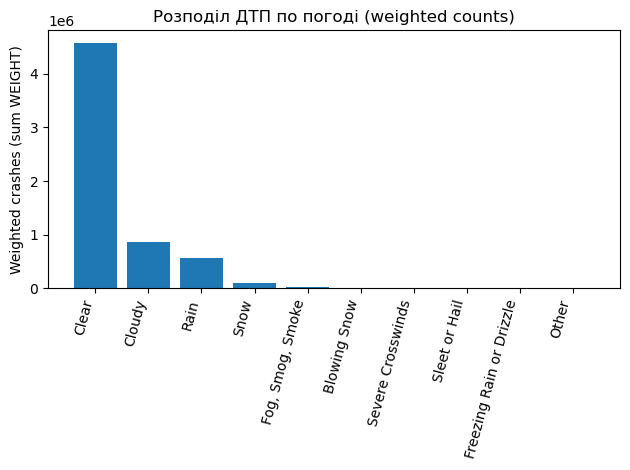

           WEATHR_IMNAME  weighted_crashes  share_%
                   Clear           4582951   74.661
                  Cloudy            860241   14.014
                    Rain            557007    9.074
                    Snow             89364    1.456
        Fog, Smog, Smoke             29629    0.483
            Blowing Snow              6385    0.104
       Severe Crosswinds              5623    0.092
           Sleet or Hail              2925    0.048
Freezing Rain or Drizzle              2554    0.042
                   Other              1277    0.021
                   Other               402    0.007


In [ ]:
# expects: acc already loaded

weather_col = "WEATHR_IMNAME" if "WEATHR_IMNAME" in acc.columns else ("WEATHERNAME" if "WEATHERNAME" in acc.columns else None)
if weather_col is None:
    raise ValueError("No weather name column found (expected WEATHR_IMNAME or WEATHERNAME).")

df = acc.copy()
df["WEIGHT"] = pd.to_numeric(df["WEIGHT"], errors="coerce")
df[weather_col] = df[weather_col].astype("string").fillna("Unknown")

tab_weather = (
    df.groupby(weather_col)["WEIGHT"].sum()
      .sort_values(ascending=False)
      .reset_index(name="w")
)
tab_weather["share"] = tab_weather["w"] / tab_weather["w"].sum()

TOPN = 10
top = tab_weather.head(TOPN).copy()
other_sum = tab_weather.iloc[TOPN:]["w"].sum()
if other_sum > 0:
    top = pd.concat(
        [top, pd.DataFrame({weather_col: ["Other"], "w": [other_sum], "share": [other_sum / tab_weather["w"].sum()]})],
        ignore_index=True
    )

plt.figure()
plt.bar(top[weather_col].astype(str), top["w"])
plt.title("Розподіл ДТП по погоді (weighted counts)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# table under plot
tab_print = top.copy()
tab_print["w"] = tab_print["w"].round(0).astype(int)
tab_print["share"] = (tab_print["share"] * 100).round(3)
tab_print = tab_print.rename(columns={"w": "weighted_crashes", "share": "share_%"})
print(tab_print.to_string(index=False))

/var/folders/53/tzqf15nx4_b7j93fk5xvykhr0000gn/T/ipykernel_77259/2396779816.py:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


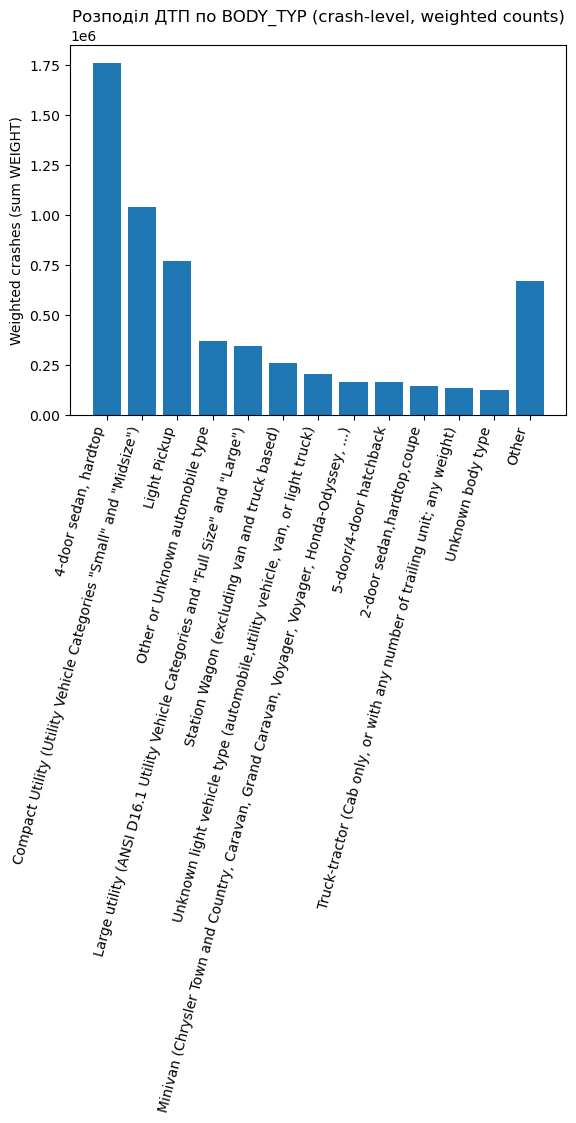

                                                                                   BODY_TYP_CRASH  weighted_crashes  share_%
                                                                            4-door sedan, hardtop           1763291   28.726
                               Compact Utility (Utility Vehicle Categories "Small" and "Midsize")           1039496   16.934
                                                                                     Light Pickup            769160   12.530
                                                                 Other or Unknown automobile type            366469    5.970
                Large utility (ANSI D16.1 Utility Vehicle Categories and "Full Size" and "Large")            341488    5.563
                                                    Station Wagon (excluding van and truck based)            259940    4.235
                     Unknown light vehicle type (automobile,utility vehicle, van, or light truck)            201497    3.283


In [ ]:
# expects: veh and acc already loaded

# choose best body type label column
if "BODY_TYPNAME" in veh.columns:
    body_col = "BODY_TYPNAME"
elif "ICFINALBODYNAME" in veh.columns:
    body_col = "ICFINALBODYNAME"
elif "VPICBODYCLASSNAME" in veh.columns:
    body_col = "VPICBODYCLASSNAME"
elif "BODY_TYP" in veh.columns:
    body_col = "BODY_TYP"
else:
    raise ValueError("No BODY_TYP name column found (BODY_TYPNAME/ICFINALBODYNAME/VPICBODYCLASSNAME/BODY_TYP).")

v = veh.copy()
v[body_col] = v[body_col].astype("string").fillna("Unknown")
v["VEH_NO"] = pd.to_numeric(v["VEH_NO"], errors="coerce")
v = v.sort_values(["CASENUM", "VEH_NO"])

# crash-level body type: take body type of smallest VEH_NO (vehicle-1 proxy)
crash_body = v.groupby("CASENUM")[body_col].first().reset_index(name="BODY_TYP_CRASH")

# attach crash weights from accident.csv (avoid WEIGHT_x/WEIGHT_y issues)
crash_w = acc[["CASENUM", "WEIGHT"]].copy()
crash_w["WEIGHT"] = pd.to_numeric(crash_w["WEIGHT"], errors="coerce")

crash_body = crash_body.merge(crash_w, on="CASENUM", how="inner").dropna(subset=["WEIGHT"])

tab_body = (
    crash_body.groupby("BODY_TYP_CRASH")["WEIGHT"].sum()
    .sort_values(ascending=False)
    .reset_index(name="w")
)
tab_body["share"] = tab_body["w"] / tab_body["w"].sum()

TOPN = 12
top = tab_body.head(TOPN).copy()
other_sum = tab_body.iloc[TOPN:]["w"].sum()
if other_sum > 0:
    top = pd.concat(
        [top, pd.DataFrame({"BODY_TYP_CRASH": ["Other"], "w": [other_sum], "share": [other_sum / tab_body["w"].sum()]})],
        ignore_index=True
    )

plt.figure()
plt.bar(top["BODY_TYP_CRASH"].astype(str), top["w"])
plt.title("Розподіл ДТП по BODY_TYP (crash-level, weighted counts)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# table under plot
tab_print = top.copy()
tab_print["w"] = tab_print["w"].round(0).astype(int)
tab_print["share"] = (tab_print["share"] * 100).round(3)
tab_print = tab_print.rename(columns={"w": "weighted_crashes", "share": "share_%"})
print(tab_print.to_string(index=False))

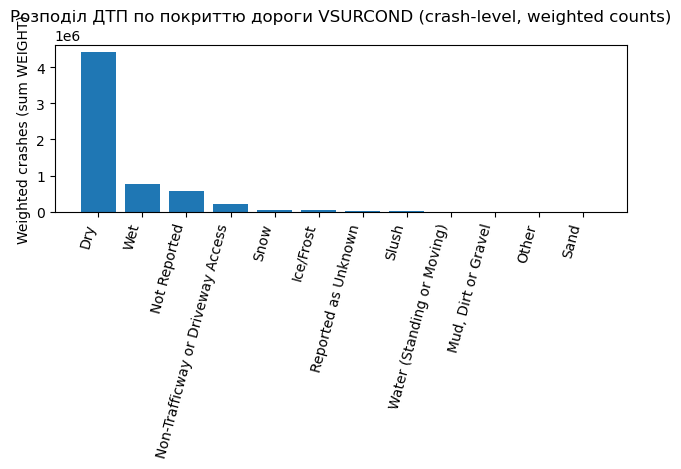

                   VSURCOND_CRASH  weighted_crashes  share_%
                              Dry           4402834   71.727
                              Wet            763421   12.437
                     Not Reported            583620    9.508
Non-Trafficway or Driveway Access            231448    3.771
                             Snow             57620    0.939
                        Ice/Frost             48653    0.793
              Reported as Unknown             16349    0.266
                            Slush             13180    0.215
       Water (Standing or Moving)             10581    0.172
              Mud, Dirt or Gravel              9487    0.155
                            Other               832    0.014
                             Sand               187    0.003
                            Other               148    0.002


In [ ]:
# expects: veh and acc already loaded

# choose surface condition label column
if "VSURCONDNAME" in veh.columns:
    surf_col = "VSURCONDNAME"
elif "VSURCOND" in veh.columns:
    surf_col = "VSURCOND"
else:
    raise ValueError("VSURCOND / VSURCONDNAME not found in vehicle.csv")

v = veh.copy()
v[surf_col] = v[surf_col].astype("string").fillna("Unknown")
v["VEH_NO"] = pd.to_numeric(v["VEH_NO"], errors="coerce")
v = v.sort_values(["CASENUM", "VEH_NO"])

# crash-level surface condition: take smallest VEH_NO per crash (vehicle-1 proxy)
crash_surf = v.groupby("CASENUM")[surf_col].first().reset_index(name="VSURCOND_CRASH")

# attach crash weights from accident.csv (avoid WEIGHT_x/WEIGHT_y issues)
crash_w = acc[["CASENUM", "WEIGHT"]].copy()
crash_w["WEIGHT"] = pd.to_numeric(crash_w["WEIGHT"], errors="coerce")

crash_surf = crash_surf.merge(crash_w, on="CASENUM", how="inner").dropna(subset=["WEIGHT"])

tab_surf = (
    crash_surf.groupby("VSURCOND_CRASH")["WEIGHT"].sum()
    .sort_values(ascending=False)
    .reset_index(name="w")
)
tab_surf["share"] = tab_surf["w"] / tab_surf["w"].sum()

TOPN = 12
top = tab_surf.head(TOPN).copy()
other_sum = tab_surf.iloc[TOPN:]["w"].sum()
if other_sum > 0:
    top = pd.concat(
        [top, pd.DataFrame({"VSURCOND_CRASH": ["Other"], "w": [other_sum], "share": [other_sum / tab_surf["w"].sum()]})],
        ignore_index=True
    )

plt.figure()
plt.bar(top["VSURCOND_CRASH"].astype(str), top["w"])
plt.title("Розподіл ДТП по покриттю дороги VSURCOND (crash-level, weighted counts)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# table under plot
tab_print = top.copy()
tab_print["w"] = tab_print["w"].round(0).astype(int)
tab_print["share"] = (tab_print["share"] * 100).round(3)
tab_print = tab_print.rename(columns={"w": "weighted_crashes", "share": "share_%"})
print(tab_print.to_string(index=False))

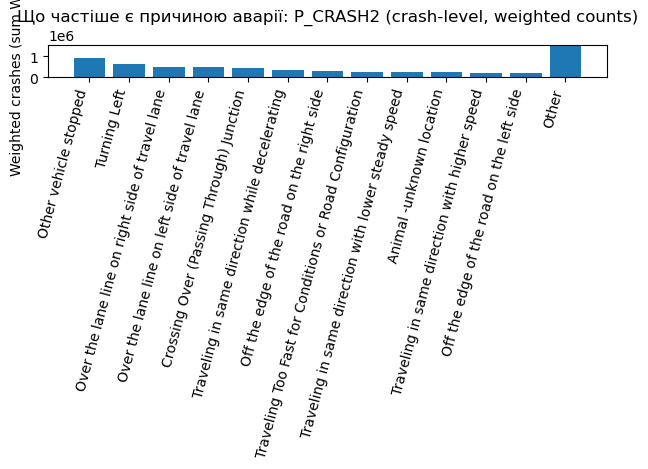

                                         P_CRASH2_CRASH  weighted_crashes  share_%
                                  Other vehicle stopped            891676   14.526
                                           Turning Left            645637   10.518
        Over the lane line on right side of travel lane            489490    7.974
         Over the lane line on left side of travel lane            477561    7.780
               Crossing Over (Passing Through) Junction            418293    6.814
         Traveling in same direction while decelerating            340947    5.554
             Off the edge of the road on the right side            284956    4.642
Traveling Too Fast for Conditions or Road Configuration            249257    4.061
    Traveling in same direction with lower steady speed            226249    3.686
                               Animal -unknown location            226239    3.686
          Traveling in same direction with higher speed            216113    3.521
    

In [13]:

# expects: veh and acc already loaded

# pick P_CRASH2 label column
if "P_CRASH2NAME" in veh.columns:
    p2_col = "P_CRASH2NAME"
elif "P_CRASH2" in veh.columns:
    p2_col = "P_CRASH2"
else:
    raise ValueError("P_CRASH2 / P_CRASH2NAME not found in vehicle.csv")

v = veh.copy()
v[p2_col] = v[p2_col].astype("string").fillna("Unknown")
v["VEH_NO"] = pd.to_numeric(v["VEH_NO"], errors="coerce")
v = v.sort_values(["CASENUM", "VEH_NO"])

# crash-level P_CRASH2: take smallest VEH_NO per crash (vehicle-1 proxy)
crash_p2 = v.groupby("CASENUM")[p2_col].first().reset_index(name="P_CRASH2_CRASH")

# attach crash weights from accident.csv
crash_w = acc[["CASENUM", "WEIGHT"]].copy()
crash_w["WEIGHT"] = pd.to_numeric(crash_w["WEIGHT"], errors="coerce")

crash_p2 = crash_p2.merge(crash_w, on="CASENUM", how="inner").dropna(subset=["WEIGHT"])

tab_p2 = (
    crash_p2.groupby("P_CRASH2_CRASH")["WEIGHT"].sum()
    .sort_values(ascending=False)
    .reset_index(name="w")
)
tab_p2["share"] = tab_p2["w"] / tab_p2["w"].sum()

TOPN = 12
top = tab_p2.head(TOPN).copy()
other_sum = tab_p2.iloc[TOPN:]["w"].sum()
if other_sum > 0:
    top = pd.concat(
        [top, pd.DataFrame({"P_CRASH2_CRASH": ["Other"], "w": [other_sum], "share": [other_sum / tab_p2["w"].sum()]})],
        ignore_index=True
    )

plt.figure()
plt.bar(top["P_CRASH2_CRASH"].astype(str), top["w"])
plt.title("Що частіше є причиною аварії: P_CRASH2 (crash-level, weighted counts)")
plt.ylabel("Weighted crashes (sum WEIGHT)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

# table under plot
tab_print = top.copy()
tab_print["w"] = tab_print["w"].round(0).astype(int)
tab_print["share"] = (tab_print["share"] * 100).round(3)
tab_print = tab_print.rename(columns={"w": "weighted_crashes", "share": "share_%"})
print(tab_print.to_string(index=False))

     WEATHER_LBL  total_weighted  serious_weighted  serious_rate_%
0   Blowing Snow    6.385404e+03        375.186757            5.88
4  Freezing Rain    2.554302e+03        101.338048            3.97
1          Clear    4.582951e+06     148785.593471            3.25
2         Cloudy    8.602413e+05      26384.187557            3.07
6     Sleet/Hail    2.924901e+03         89.112577            3.05
3            Fog    2.962869e+04        853.313713            2.88
5           Rain    5.570070e+05      13818.136429            2.48
7           Snow    8.936351e+04       1380.841995            1.55


/var/folders/53/tzqf15nx4_b7j93fk5xvykhr0000gn/T/ipykernel_47462/3957119587.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('WEATHER_LBL').apply(


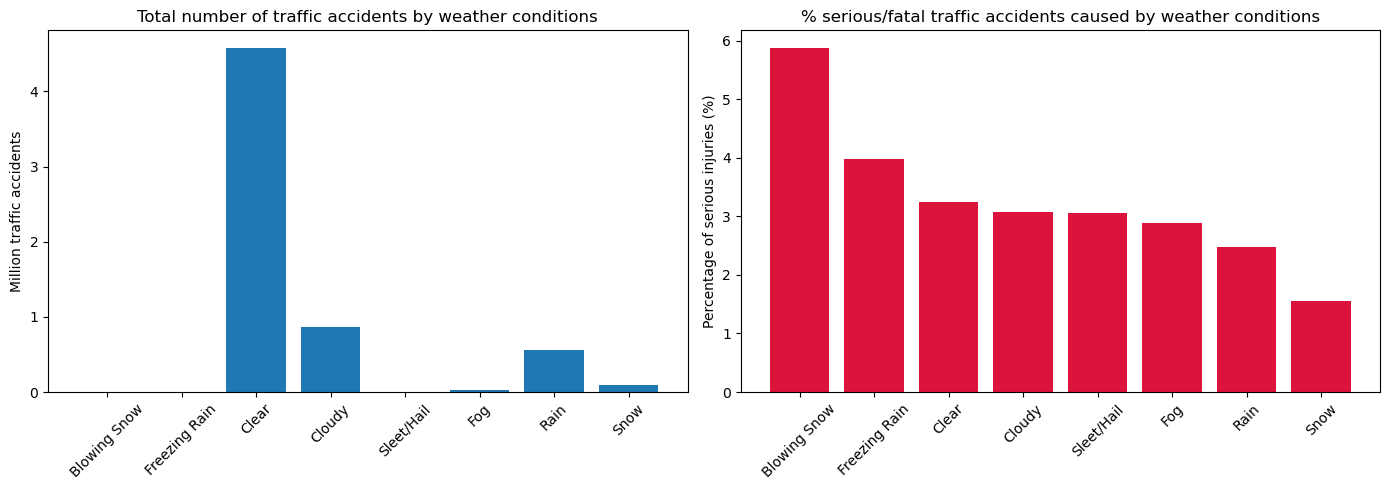

In [6]:
# Частка серйозних травм по погоді (нормалізована)
df = acc.copy()
df['WEIGHT'] = pd.to_numeric(df['WEIGHT'], errors='coerce')
df['WEATHR_IM'] = pd.to_numeric(df['WEATHR_IM'], errors='coerce')
df['MAXSEV_IM'] = pd.to_numeric(df['MAXSEV_IM'], errors='coerce')

# Залишаємо тільки відомі погодні умови
weather_map = {1:'Clear', 2:'Rain', 3:'Sleet/Hail', 4:'Snow',
               5:'Fog', 10:'Cloudy', 11:'Blowing Snow', 12:'Freezing Rain'}
df = df[df['WEATHR_IM'].isin(weather_map.keys())].copy()
df['WEATHER_LBL'] = df['WEATHR_IM'].map(weather_map)

# Серйозна травма = MAX_SEV 3 або 4
df['SERIOUS'] = df['MAXSEV_IM'].isin([3, 4]).astype(int)

# Зважена частка серйозних по погоді
result = df.groupby('WEATHER_LBL').apply(
    lambda g: pd.Series({
        'total_weighted':    g['WEIGHT'].sum(),
        'serious_weighted':  (g['WEIGHT'] * g['SERIOUS']).sum(),
    })
).reset_index()

result['serious_rate_%'] = (result['serious_weighted'] / result['total_weighted'] * 100).round(2)
result = result.sort_values('serious_rate_%', ascending=False)
print(result)

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ліво — абсолютна кількість (те що ти вже бачив)
axes[0].bar(result['WEATHER_LBL'], result['total_weighted'] / 1e6)
axes[0].set_title('Total number of traffic accidents by weather conditions')
axes[0].set_ylabel('Million traffic accidents')
axes[0].tick_params(axis='x', rotation=45)

# Право — відносна частка серйозних (новий погляд)
axes[1].bar(result['WEATHER_LBL'], result['serious_rate_%'], color='crimson')
axes[1].set_title('% serious/fatal traffic accidents caused by weather conditions')
axes[1].set_ylabel('Percentage of serious injuries (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

                     TIME_CAT         total  fatal_rate_%  serious_rate_%
0              0. Night (0-5)  5.045247e+05          1.59            5.68
1  1. Morning rush hour (6-9)  1.068637e+06          0.43            2.29
2              2. Day (10-15)  2.127886e+06          0.40            2.54
3        3. Rush hour (16-19)  1.662839e+06          0.49            2.92
4     4. Late evening (20-23)  7.744716e+05          1.07            4.72


/var/folders/53/tzqf15nx4_b7j93fk5xvykhr0000gn/T/ipykernel_47462/3984851997.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('TIME_CAT').apply(


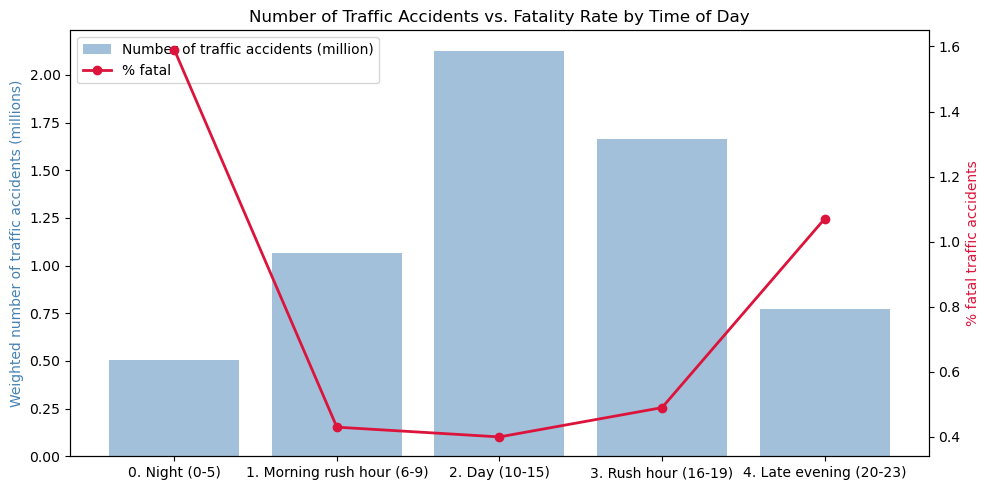

In [5]:
df = acc.copy()
df['WEIGHT'] = pd.to_numeric(df['WEIGHT'], errors='coerce')
df['HOUR_USE'] = pd.to_numeric(df['HOUR_IM'], errors='coerce')
df['MAXSEV_IM'] = pd.to_numeric(df['MAXSEV_IM'], errors='coerce')
df = df.dropna(subset=['HOUR_USE', 'MAXSEV_IM', 'WEIGHT'])
df = df[(df['HOUR_USE'] >= 0) & (df['HOUR_USE'] <= 23)]

# Категорії часу
def time_category(h):
    if 0 <= h <= 5:   return '0. Night (0-5)'
    elif 6 <= h <= 9:  return '1. Morning rush hour (6-9)'
    elif 10 <= h <= 15: return '2. Day (10-15)'
    elif 16 <= h <= 19: return '3. Rush hour (16-19)'
    else:              return '4. Late evening (20-23)'

df['TIME_CAT'] = df['HOUR_USE'].apply(time_category)
df['FATAL'] = (df['MAXSEV_IM'] == 4).astype(int)
df['SERIOUS'] = df['MAXSEV_IM'].isin([3, 4]).astype(int)

result = df.groupby('TIME_CAT').apply(
    lambda g: pd.Series({
        'total':           g['WEIGHT'].sum(),
        'fatal_weighted':  (g['WEIGHT'] * g['FATAL']).sum(),
        'serious_weighted':(g['WEIGHT'] * g['SERIOUS']).sum(),
    })
).reset_index()

result['fatal_rate_%']   = (result['fatal_weighted']   / result['total'] * 100).round(2)
result['serious_rate_%'] = (result['serious_weighted'] / result['total'] * 100).round(2)

print(result[['TIME_CAT','total','fatal_rate_%','serious_rate_%']])

# Подвійний графік
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(result['TIME_CAT'], result['total']/1e6,
               alpha=0.5, color='steelblue', label='Number of traffic accidents (million)')
ax2.plot(result['TIME_CAT'], result['fatal_rate_%'],
         color='crimson', marker='o', linewidth=2, label="% fatal")

ax1.set_ylabel('Weighted number of traffic accidents (millions)', color='steelblue')
ax2.set_ylabel('% fatal traffic accidents', color='crimson')
ax1.set_title('Number of Traffic Accidents vs. Fatality Rate by Time of Day')
plt.xticks(rotation=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/53/tzqf15nx4_b7j93fk5xvykhr0000gn/T/ipykernel_47462/1705427409.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = p.groupby(['AGE_GRP', 'IS_NIGHT'], observed=True).apply(


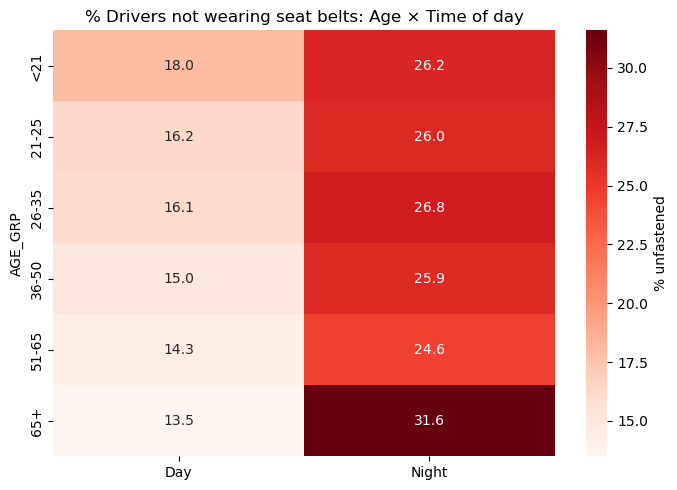

In [7]:
p = per.copy()
p['WEIGHT'] = pd.to_numeric(p['WEIGHT'], errors='coerce')
p['AGE'] = pd.to_numeric(
    p['AGE_IM'] if 'AGE_IM' in p.columns else p['AGE'],
    errors='coerce'
)

# Фільтр: тільки водії (PER_TYP=1)
p = p[p['PER_TYP'] == 1].copy()

# Вік групи
age_bins  = [0, 20, 25, 35, 50, 65, 120]
age_lbls  = ['<21','21-25','26-35','36-50','51-65','65+']
p['AGE_GRP'] = pd.cut(p['AGE'], bins=age_bins, labels=age_lbls)

# Ремінь
rest_col = 'REST_USE' if 'REST_USE' in p.columns else 'RESTUSE'
p['BUCKLED'] = pd.to_numeric(p[rest_col], errors='coerce').isin([3])  # Shoulder+Lap

# Час доби з accident
hour_df = acc[['CASENUM','HOUR_IM']].copy()
hour_df['HOUR_IM'] = pd.to_numeric(hour_df['HOUR_IM'], errors='coerce')
hour_df['IS_NIGHT'] = hour_df['HOUR_IM'].between(21, 23) | hour_df['HOUR_IM'].between(0, 5)

p = p.merge(hour_df, on='CASENUM', how='left')

# Частка непристебнутих по віку і часу доби
result = p.groupby(['AGE_GRP', 'IS_NIGHT'], observed=True).apply(
    lambda g: pd.Series({
        'total':      g['WEIGHT'].sum(),
        'unbuckled':  g.loc[~g['BUCKLED'], 'WEIGHT'].sum(),
    })
).reset_index()

result['unbuckled_%'] = (result['unbuckled'] / result['total'] * 100).round(1)

# Pivot для heatmap
pivot = result.pivot(index='AGE_GRP', columns='IS_NIGHT', values='unbuckled_%')
pivot.columns = ['Day', 'Night']

import seaborn as sns
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': '% unfastened'})
plt.title('% Drivers not wearing seat belts: Age × Time of day')
plt.tight_layout()
plt.show()

/var/folders/53/tzqf15nx4_b7j93fk5xvykhr0000gn/T/ipykernel_47462/3608854275.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly = df.groupby('HOUR_USE').apply(


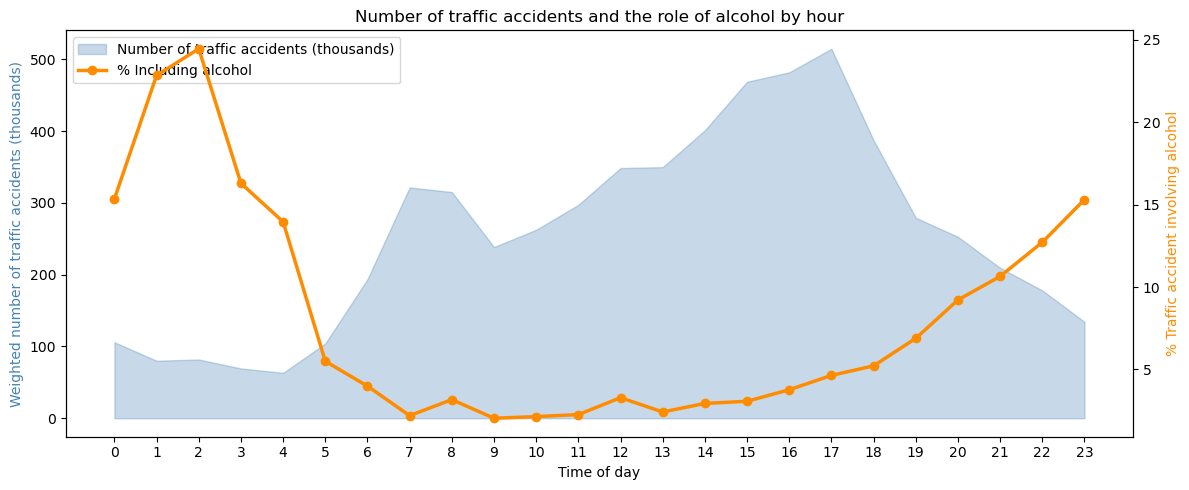

In [14]:
df = acc.copy()
df['WEIGHT'] = pd.to_numeric(df['WEIGHT'], errors='coerce')
df['HOUR_USE'] = pd.to_numeric(df['HOUR_IM'], errors='coerce')
df['ALCHL_IM'] = pd.to_numeric(df['ALCHL_IM'], errors='coerce')
df = df.dropna(subset=['HOUR_USE','ALCHL_IM','WEIGHT'])
df = df[(df['HOUR_USE'] >= 0) & (df['HOUR_USE'] <= 23)]

df['ALCOHOL_YES'] = (df['ALCHL_IM'] == 1).astype(int)

hourly = df.groupby('HOUR_USE').apply(
    lambda g: pd.Series({
        'total':        g['WEIGHT'].sum(),
        'alcohol_w':    (g['WEIGHT'] * g['ALCOHOL_YES']).sum(),
    })
).reset_index()

hourly['alcohol_%'] = (hourly['alcohol_w'] / hourly['total'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.fill_between(hourly['HOUR_USE'], hourly['total']/1e3,
                 alpha=0.3, color='steelblue', label='Number of traffic accidents (thousands)')
ax2.plot(hourly['HOUR_USE'], hourly['alcohol_%'],
         color='darkorange', marker='o', linewidth=2.5, label='% Including alcohol')

ax1.set_xlabel('Time of day')
ax1.set_ylabel('Weighted number of traffic accidents (thousands)', color='steelblue')
ax2.set_ylabel('% Traffic accident involving alcohol', color='darkorange')
ax1.set_title('Number of traffic accidents and the role of alcohol by hour')
ax1.set_xticks(range(24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()